## **설정**

In [1]:
## Google Drive Amount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
## Import libaries
import pandas as pd
import numpy as np

import os

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## Setting
base_path = '/content/drive/MyDrive/CS/'

## **데이터 불러오기**

In [4]:
## Load the data
file_path = os.path.join(base_path, 'Data', 'fred_md_raw.csv')
df = pd.read_csv(file_path)

df.head()

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
0,Transform:,5.000,5.0,5.000,5.0000,5.00000,5.0000,5.0000,5.0000,5.0000,...,6.000,6.000,6.00,6.00,6.00,2.0,6.0,6.0,6.0000,1.0
1,1/1/1959,2583.560,2426.0,15.188,276676.8154,17689.23968,21.9998,23.6312,22.5507,32.1377,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.0,12298.0,84.2043,NaN
2,2/1/1959,2593.596,2434.8,15.346,278713.9773,17819.01912,22.4306,23.9501,22.7461,32.3734,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.0,12298.0,83.5280,NaN
3,3/1/1959,2610.396,2452.7,15.491,277775.2539,17967.91336,22.7538,24.0951,22.8577,32.3734,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.0,12349.0,81.6405,NaN
4,4/1/1959,2627.446,2470.0,15.435,283362.7075,17978.97983,23.2384,24.4431,23.1926,32.8841,...,18.300,10.221,2.16,2.47,2.08,NaN,6620.0,12484.0,81.8099,NaN


In [5]:
df.columns

Index(['sasdate', 'RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx',
       'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD',
       ...
       'DNDGRG3M086SBEA', 'DSERRG3M086SBEA', 'CES0600000008', 'CES2000000008',
       'CES3000000008', 'UMCSENTx', 'DTCOLNVHFNM', 'DTCTHFNM', 'INVEST',
       'VIXCLSx'],
      dtype='object', length=127)

## **데이터 전처리**

In [ ]:
## 데이터 전처리

# 첫번째 행 제거
df_cleaned = df.iloc[1:].copy()

# 날짜 컬럼 처리
df_cleaned['sasdate'] = pd.to_datetime(df_cleaned['sasdate'])

# 기간 설정 : 1997년 1월~2024년 12월
# 근데 거시 경제 정보는 지연된 정보라고 해서 1995년 12월부터 수집
macro_df = df_cleaned[(df_cleaned['sasdate'] >= '1995-12-01') & (df_cleaned['sasdate'] <= '2024-12-01')].copy()
macro_df.reset_index(drop=True, inplace=True)

In [ ]:
display(macro_df.head())
display(macro_df.tail())

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
0,1995-12-01,9396.526,8094.0,56.158,857932.126,204032.0,73.0305,82.3776,80.4264,92.5508,...,69.665,58.318,13.09,14.77,12.49,91.0,81073.0,285844.04,893.1924,12.2880
1,1996-01-01,9428.309,8102.2,55.905,849368.258,203793.0,72.6125,81.5501,79.5142,91.4690,...,70.054,58.393,13.23,15.00,12.60,89.3,82026.0,285496.58,890.7512,15.0690
2,1996-02-01,9506.777,8172.2,56.334,857042.936,206875.0,73.6752,82.8225,80.9324,92.8050,...,70.214,58.501,13.18,14.91,12.56,88.5,84076.0,286101.17,898.9080,16.5672
3,1996-03-01,9539.993,8196.0,56.607,857469.507,207650.0,73.5850,82.6687,80.5749,92.2432,...,70.645,58.634,13.15,14.93,12.50,93.7,84340.0,287684.78,895.5430,18.7075
4,1996-04-01,9565.104,8210.4,56.816,865141.781,209294.0,74.3172,83.5322,81.6807,93.0933,...,71.093,58.815,13.30,14.98,12.69,92.7,86461.0,289724.92,896.9737,16.7505


,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
344,2024-08-01,20189.814,16494.5,121.482,1518385.0,697039.0,100.4309,96.9989,97.1395,98.7118,...,119.487,128.569,31.25,35.91,27.89,67.9,551667.22,933066.90,5316.5838,19.6750
345,2024-09-01,20216.213,16500.8,122.100,1530455.0,703285.0,99.8084,96.2724,96.1195,98.5314,...,119.226,129.027,31.45,36.18,28.01,70.1,553347.06,934283.59,5356.9074,17.6597
346,2024-10-01,20263.282,16531.5,122.250,1526325.0,707613.0,99.4695,95.5161,95.0715,98.0825,...,119.223,129.521,31.53,36.27,28.07,70.5,554919.46,937096.10,5393.6275,19.9478
347,2024-11-01,20316.650,16590.1,122.639,1535297.0,712145.0,99.2925,95.3153,94.9111,97.3918,...,119.235,129.744,31.59,36.26,28.22,71.8,556011.41,938335.20,5381.0274,15.9822
348,2024-12-01,20338.298,16606.6,123.512,1547485.0,717662.0,100.3273,96.3927,95.9708,98.1705,...,119.756,130.198,31.72,36.43,28.33,74.0,559364.75,943484.76,5368.1367,15.6997


### **결측치 처리**

In [ ]:
## 결측치 확인
null_counts = macro_df.isnull().sum()
display(null_counts[null_counts > 0])

,0
CP3Mx,1
COMPAPFFx,1


In [ ]:
# Null 값 있는 컬럼명 추출
null_columns_list = null_counts[null_counts > 0].index.tolist()

In [ ]:
# Null 값이 있는 행과 컬럼 확인
rows_with_null = macro_df[macro_df.isnull().any(axis=1)]
display(rows_with_null[['sasdate'] + null_columns_list])

,sasdate,CP3Mx,COMPAPFFx
292,2020-04-01,NaN,NaN


- `CP3Mx`
  - 3-Month AA Financial Commercial Paper Rate
  - 만기가 3개월이고 신용등급이 AA(우량등급)인 금융회사가 발행한 기업어음(Commercial Paper)의 시장 이자율
- `COMPAPFFx`
  - 3-Month Commercial Paper Minus FEDFUNDS
  - 3개월 만기 기업어음(CP) 금리에서 연방기금(Fed Funds) 금리를 뺀 값
  - [FRED-MD 사이트의 변수 설명](https://fred.stlouisfed.org/series/CPFFM)
    - Series is calculated as the spread between 3-Month AA Financial Commercial Paper (RIFSPPFAAD90NBM) and Effective Federal Funds Rate
    - `CP3Mx`- `FEDFUNDS`인 듯


- COMPAPFFx가 `CP3Mx`- `FEDFUNDS`인지 확인

In [ ]:
# 두 변수 관계 확인
compare_null_column = pd.DataFrame({
    'CP3Mx - FEDFUNDS': macro_df['CP3Mx'] - macro_df['FEDFUNDS'],
    'COMPAPFFx': macro_df['COMPAPFFx']
})

compare_null_column

,CP3Mx - FEDFUNDS,COMPAPFFx
0,0.04,0.04
1,-0.16,-0.16
2,-0.07,-0.07
3,0.00,0.00
4,0.17,0.17
...,...,...
344,-0.21,-0.21
345,-0.27,-0.27
346,-0.21,-0.21
347,-0.11,-0.11


In [ ]:
# 차이를 구해서 정확히 비교
(compare_null_column['CP3Mx - FEDFUNDS']-compare_null_column['COMPAPFFx']).fillna(0).sum()

np.float64(8.108097526715596e-15)

- `CP3Mx`만 결측치 채워서 `COMPAPFFx` 값 구하면 된다.
- 결측치가 하나이니 선형 보간법을 써도 되지 않을까?

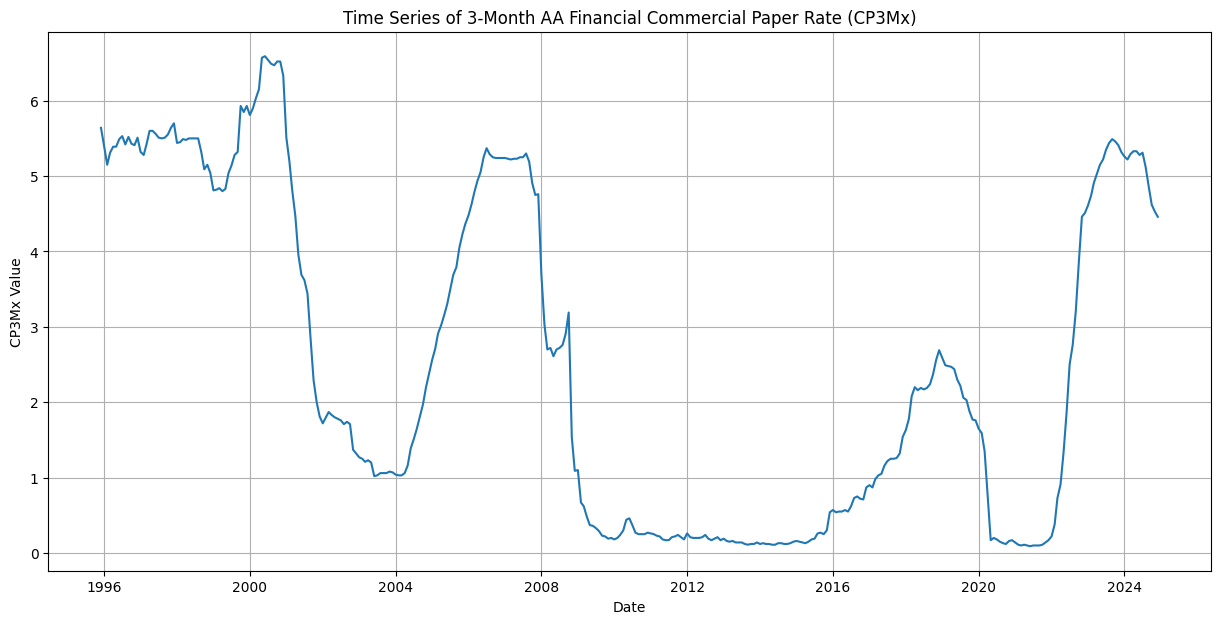

In [ ]:
# CP3Mx 컬럼의 Time-Series Plot
plt.figure(figsize=(15, 7))
sns.lineplot(x='sasdate', y='CP3Mx', data=macro_df)
plt.title('Time Series of 3-Month AA Financial Commercial Paper Rate (CP3Mx)')
plt.xlabel('Date')
plt.ylabel('CP3Mx Value')
plt.grid(True)
plt.show()

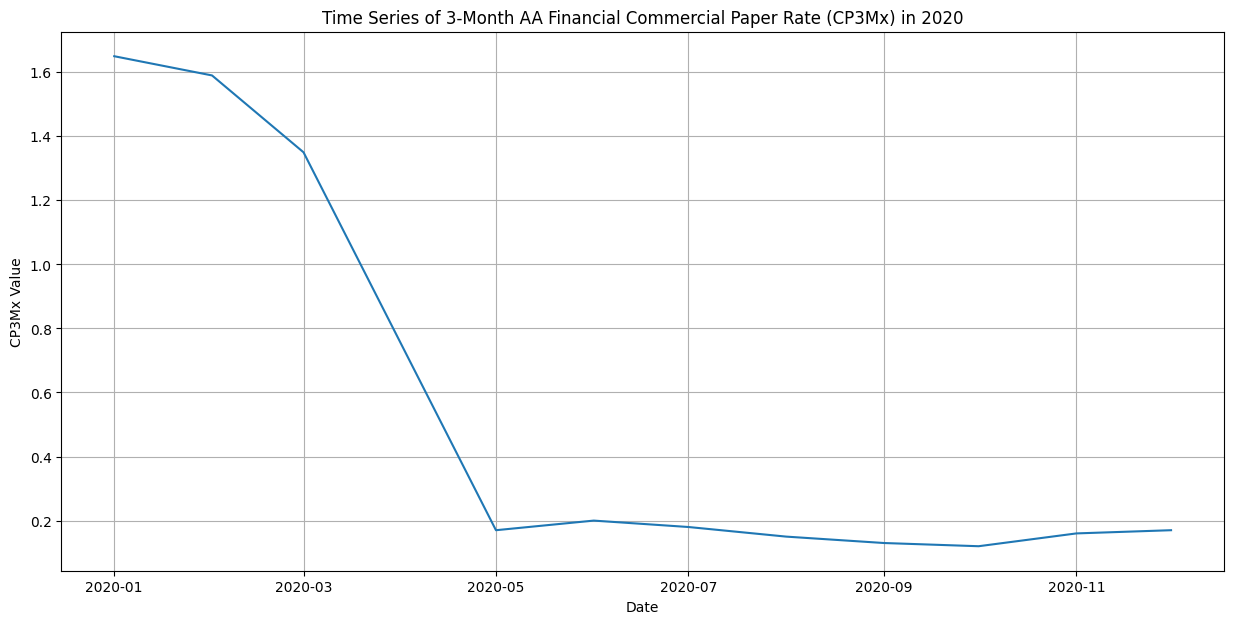

In [ ]:
# Filter macro_df for the year 2020
macro_df_2020 = macro_df[macro_df['sasdate'].dt.year == 2020]

plt.figure(figsize=(15, 7))
sns.lineplot(x='sasdate', y='CP3Mx', data=macro_df_2020)
plt.title('Time Series of 3-Month AA Financial Commercial Paper Rate (CP3Mx) in 2020')
plt.xlabel('Date')
plt.ylabel('CP3Mx Value')
plt.grid(True)
plt.show()

- 선형 보간법을 적용해도 하향하고 있는 추세를 잘 나타낼 것 같다.

In [ ]:
## 결측치 처리 : CP3Mx
macro_df['CP3Mx'] = macro_df['CP3Mx'].interpolate(method='linear')
display(macro_df['CP3Mx'].isnull().sum())

np.int64(0)

In [ ]:
## 결측치 처리 : COMPAPFFx
macro_df['COMPAPFFx'] = macro_df['COMPAPFFx'].fillna(macro_df['CP3Mx'] - macro_df['FEDFUNDS'])
display(macro_df['COMPAPFFx'].isnull().sum())

np.int64(0)

### **시차(lag) 반영**
- `microeconomic 변수설명` 파일 참고
- 변수 설명에 있는 모든 변수가 다 있는 게 아니다. 134개로 되어 있는데 127개만 있다.

- `S&P PE ratio`
  - (1) The S&P PE ratio (series 83) is taken from Shiller’s website and is released with roughly a 6-month lag. Hence observations are missing at the end of the sample.

- (2) The Michigan Survey of Consumer Sentiment (series 130) is available only quarterly prior to 1977:11, and recent data are available in FRED with a 1-year lag.

In [ ]:
## S&P PE ratio
# 변수명 확인
s_and_p_columns = [col for col in macro_df.columns if col.startswith('S&P')]
display(s_and_p_columns)

['S&P 500', 'S&P div yield', 'S&P PE ratio']

In [ ]:
# lag 적용
macro_df1 = macro_df.copy()
macro_df1['S&P PE ratio_lag6'] = macro_df1['S&P PE ratio'].shift(6)
display(macro_df1[['sasdate', 'S&P PE ratio', 'S&P PE ratio_lag6']].head(10))

,sasdate,S&P PE ratio,S&P PE ratio_lag6
0,1995-12-01,18.195423,NaN
1,1996-01-01,17.970413,NaN
2,1996-02-01,18.849705,NaN
3,1996-03-01,18.624445,NaN
4,1996-04-01,18.530681,NaN
5,1996-05-01,18.888330,NaN
6,1996-06-01,19.091110,18.195423
7,1996-07-01,18.378768,17.970413
8,1996-08-01,18.893067,18.849705
9,1996-09-01,19.193535,18.624445


In [ ]:
## UMCSENTx
# UMCSENTx 컬럼이 있는지 확인
if 'UMCSENTx' in macro_df.columns:
    display(macro_df['UMCSENTx'].head())
else:
    print("The column 'UMCSENTx' does not exist in macro_df.")

,UMCSENTx
0,91.0
1,89.3
2,88.5
3,93.7
4,92.7


In [ ]:
# lag 적용
macro_df1['UMCSENTx_lag12'] = macro_df1['UMCSENTx'].shift(12)
display(macro_df1[['sasdate', 'UMCSENTx', 'UMCSENTx_lag12']].head(10))

,sasdate,UMCSENTx,UMCSENTx_lag12
0,1995-12-01,91.0,NaN
1,1996-01-01,89.3,NaN
2,1996-02-01,88.5,NaN
3,1996-03-01,93.7,NaN
4,1996-04-01,92.7,NaN
5,1996-05-01,89.4,NaN
6,1996-06-01,92.4,NaN
7,1996-07-01,94.7,NaN
8,1996-08-01,95.3,NaN
9,1996-09-01,94.7,NaN


In [ ]:
# 기존 컬럼 제거
macro_df1.drop(columns=['S&P PE ratio', 'UMCSENTx'], inplace=True)

# 기간 설정 : 1997년 1월~2024년 12월
macro_df1_filter = macro_df1[(macro_df1['sasdate'] >= '1997-01-01') & (macro_df1['sasdate'] <= '2024-12-01')].copy()
macro_df1_filter.reset_index(drop=True, inplace=True)

macro_df1_filter.head()

,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,...,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx,S&P PE ratio_lag6,UMCSENTx_lag12
0,1997-01-01,9834.790,8477.0,58.162,898609.0,218124.0,77.6562,86.9397,84.8739,94.8103,...,60.139,13.64,15.46,12.99,89237.47,318279.13,899.3820,21.0313,18.378768,89.3
1,1997-02-01,9865.668,8516.0,58.285,916958.0,219587.0,78.5833,87.8518,85.6843,95.3979,...,60.305,13.67,15.49,13.00,89838.70,318417.81,900.6754,21.6478,18.893067,88.5
2,1997-03-01,9912.112,8555.7,58.441,917376.0,221189.0,79.0820,88.5539,86.5171,96.0760,...,60.465,13.69,15.46,13.03,88875.91,321671.10,912.9702,22.3035,19.193535,93.7
3,1997-04-01,9919.423,8568.6,58.438,920441.0,217925.0,79.1747,88.4091,86.2297,95.1486,...,60.618,13.71,15.52,13.03,86699.46,327250.65,927.9867,21.5077,19.897600,92.7
4,1997-05-01,9964.583,8614.9,58.474,920215.0,217771.0,79.6133,89.0298,86.9100,95.8854,...,60.676,13.76,15.58,13.07,88921.74,330125.91,924.3954,21.9276,20.774706,89.4


In [ ]:
# 결측치 없는지 확인
display(sum(macro_df1_filter.isnull().sum()))

0

In [ ]:
## Save
output_file_path = os.path.join(base_path, 'myData', 'macroeco_data.csv')
macro_df.to_csv(output_file_path, index=False)

#### **Other Columns : 1개월**

In [ ]:
## 다른 컬럼도 1개월 시차 적용
exclude_from_lag1 = ['sasdate', 'S&P PE ratio_lag6', 'UMCSENTx_lag12']
columns_to_lag1 = [col for col in macro_df1.columns if col not in exclude_from_lag1]

macro_df_lag1 = macro_df1.copy()

for col in columns_to_lag1:
  macro_df_lag1[col] = macro_df_lag1[col].shift(1)
  macro_df_lag1.rename(columns={col: f'{col}_lag1'}, inplace=True)

display(macro_df_lag1.head())

,sasdate,RPI_lag1,W875RX1_lag1,DPCERA3M086SBEA_lag1,CMRMTSPLx_lag1,RETAILx_lag1,INDPRO_lag1,IPFPNSS_lag1,IPFINAL_lag1,IPCONGD_lag1,...,DSERRG3M086SBEA_lag1,CES0600000008_lag1,CES2000000008_lag1,CES3000000008_lag1,DTCOLNVHFNM_lag1,DTCTHFNM_lag1,INVEST_lag1,VIXCLSx_lag1,S&P PE ratio_lag6,UMCSENTx_lag12
0,1995-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1996-01-01,9396.526,8094.0,56.158,857932.126,204032.0,73.0305,82.3776,80.4264,92.5508,...,58.318,13.09,14.77,12.49,81073.0,285844.04,893.1924,12.2880,NaN,NaN
2,1996-02-01,9428.309,8102.2,55.905,849368.258,203793.0,72.6125,81.5501,79.5142,91.4690,...,58.393,13.23,15.00,12.60,82026.0,285496.58,890.7512,15.0690,NaN,NaN
3,1996-03-01,9506.777,8172.2,56.334,857042.936,206875.0,73.6752,82.8225,80.9324,92.8050,...,58.501,13.18,14.91,12.56,84076.0,286101.17,898.9080,16.5672,NaN,NaN
4,1996-04-01,9539.993,8196.0,56.607,857469.507,207650.0,73.5850,82.6687,80.5749,92.2432,...,58.634,13.15,14.93,12.50,84340.0,287684.78,895.5430,18.7075,NaN,NaN


In [ ]:
# 기간 설정 : 1997년 1월~2024년 12월
macro_df_lag1_filter = macro_df_lag1[(macro_df_lag1['sasdate'] >= '1997-01-01') & (macro_df_lag1['sasdate'] <= '2024-12-01')].copy()
macro_df_lag1_filter.reset_index(drop=True, inplace=True)

macro_df_lag1_filter.head()

,sasdate,RPI_lag1,W875RX1_lag1,DPCERA3M086SBEA_lag1,CMRMTSPLx_lag1,RETAILx_lag1,INDPRO_lag1,IPFPNSS_lag1,IPFINAL_lag1,IPCONGD_lag1,...,DSERRG3M086SBEA_lag1,CES0600000008_lag1,CES2000000008_lag1,CES3000000008_lag1,DTCOLNVHFNM_lag1,DTCTHFNM_lag1,INVEST_lag1,VIXCLSx_lag1,S&P PE ratio_lag6,UMCSENTx_lag12
0,1997-01-01,9778.588,8442.0,57.888,887167.277,215690.0,77.5333,86.9463,84.9218,95.0441,...,60.034,13.59,15.29,12.95,88771.37,315926.58,893.5559,19.9415,18.378768,89.3
1,1997-02-01,9834.790,8477.0,58.162,898609.000,218124.0,77.6562,86.9397,84.8739,94.8103,...,60.139,13.64,15.46,12.99,89237.47,318279.13,899.3820,21.0313,18.893067,88.5
2,1997-03-01,9865.668,8516.0,58.285,916958.000,219587.0,78.5833,87.8518,85.6843,95.3979,...,60.305,13.67,15.49,13.00,89838.70,318417.81,900.6754,21.6478,19.193535,93.7
3,1997-04-01,9912.112,8555.7,58.441,917376.000,221189.0,79.0820,88.5539,86.5171,96.0760,...,60.465,13.69,15.46,13.03,88875.91,321671.10,912.9702,22.3035,19.897600,92.7
4,1997-05-01,9919.423,8568.6,58.438,920441.000,217925.0,79.1747,88.4091,86.2297,95.1486,...,60.618,13.71,15.52,13.03,86699.46,327250.65,927.9867,21.5077,20.774706,89.4


In [ ]:
# 결측치 없는지 확인
display(sum(macro_df_lag1_filter.isnull().sum()))

0

In [ ]:
## Save
output_file_path = os.path.join(base_path, 'myData', 'macroeco_data_lag1.csv')
macro_df.to_csv(output_file_path, index=False)

#### **Other Columns : 3개월**

In [ ]:
## 다른 컬럼도 3개월 시차 적용
exclude_from_lag3 = ['sasdate', 'S&P PE ratio_lag6', 'UMCSENTx_lag12']
columns_to_lag3 = [col for col in macro_df1.columns if col not in exclude_from_lag3]

macro_df_lag3 = macro_df1.copy()

for col in columns_to_lag3:
  macro_df_lag3[col] = macro_df_lag3[col].shift(3)
  macro_df_lag3.rename(columns={col: f'{col}_lag3'}, inplace=True)

display(macro_df_lag3.head())

,sasdate,RPI_lag3,W875RX1_lag3,DPCERA3M086SBEA_lag3,CMRMTSPLx_lag3,RETAILx_lag3,INDPRO_lag3,IPFPNSS_lag3,IPFINAL_lag3,IPCONGD_lag3,...,DSERRG3M086SBEA_lag3,CES0600000008_lag3,CES2000000008_lag3,CES3000000008_lag3,DTCOLNVHFNM_lag3,DTCTHFNM_lag3,INVEST_lag3,VIXCLSx_lag3,S&P PE ratio_lag6,UMCSENTx_lag12
0,1995-12-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1996-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1996-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1996-03-01,9396.526,8094.0,56.158,857932.126,204032.0,73.0305,82.3776,80.4264,92.5508,...,58.318,13.09,14.77,12.49,81073.0,285844.04,893.1924,12.288,NaN,NaN
4,1996-04-01,9428.309,8102.2,55.905,849368.258,203793.0,72.6125,81.5501,79.5142,91.4690,...,58.393,13.23,15.00,12.60,82026.0,285496.58,890.7512,15.069,NaN,NaN


In [ ]:
# 기간 설정 : 1997년 1월~2024년 12월
macro_df_lag3_filter = macro_df_lag3[(macro_df_lag3['sasdate'] >= '1997-01-01') & (macro_df_lag3['sasdate'] <= '2024-12-01')].copy()
macro_df_lag3_filter.reset_index(drop=True, inplace=True)

macro_df_lag3_filter.head()

,sasdate,RPI_lag3,W875RX1_lag3,DPCERA3M086SBEA_lag3,CMRMTSPLx_lag3,RETAILx_lag3,INDPRO_lag3,IPFPNSS_lag3,IPFINAL_lag3,IPCONGD_lag3,...,DSERRG3M086SBEA_lag3,CES0600000008_lag3,CES2000000008_lag3,CES3000000008_lag3,DTCOLNVHFNM_lag3,DTCTHFNM_lag3,INVEST_lag3,VIXCLSx_lag3,S&P PE ratio_lag6,UMCSENTx_lag12
0,1997-01-01,9710.076,8375.9,57.516,887041.109,215526.0,76.3384,85.4816,83.3212,93.6257,...,59.808,13.48,15.23,12.83,89378.31,310021.81,895.0207,17.6269,18.378768,89.3
1,1997-02-01,9741.024,8405.9,57.659,893603.096,215167.0,77.0397,86.4399,84.3387,94.7926,...,59.937,13.52,15.25,12.88,89293.19,311893.89,896.8804,17.1635,18.893067,88.5
2,1997-03-01,9778.588,8442.0,57.888,887167.277,215690.0,77.5333,86.9463,84.9218,95.0441,...,60.034,13.59,15.29,12.95,88771.37,315926.58,893.5559,19.9415,19.193535,93.7
3,1997-04-01,9834.790,8477.0,58.162,898609.000,218124.0,77.6562,86.9397,84.8739,94.8103,...,60.139,13.64,15.46,12.99,89237.47,318279.13,899.3820,21.0313,19.897600,92.7
4,1997-05-01,9865.668,8516.0,58.285,916958.000,219587.0,78.5833,87.8518,85.6843,95.3979,...,60.305,13.67,15.49,13.00,89838.70,318417.81,900.6754,21.6478,20.774706,89.4


In [ ]:
# 결측치 없는지 확인
display(sum(macro_df_lag3_filter.isnull().sum()))

0

In [ ]:
## Save
output_file_path = os.path.join(base_path, 'myData', 'macroeco_data_lag3.csv')
macro_df.to_csv(output_file_path, index=False)